# Seasonal Agriculture Performance Analysis & Predictive Modeling

---

### Project & Intern Details
| Field | Details |
| :--- | :--- |
| **Intern Name** | **Sathiyamoorthi K** |
| **Institution** | **IFET College of Engineering** |
| **AICTE Student ID** | `STU663c9352627131715245906` |
| **Internship ID** | `INTERNSHIP_17830691666a4779eecfe8a` |
| **Email** | [kkssathiyamoorthi@gmail.com](mailto:kkssathiyamoorthi@gmail.com) |
| **GitHub** | [@ksmashhero06](https://github.com/ksmashhero06) |
| **Program** | Edunet Foundation x VOIS for Tech (Vodafone Idea Foundation) - Data Analytics Internship |
| **Duration** | 10th August 2026 – 10th September 2026 (4 Weeks) |
| **Domain** | Agriculture & Smart Farming |
| **Tech Stack** | Python, Pandas, NumPy, Scikit-Learn, XGBoost, SciPy, Matplotlib, Seaborn, Joblib |

---

## 1. Project Background & Problem Statement

This project is part of the **Edunet Foundation Internship** powered by **VOIS for Tech** (Vodafone Idea Foundation), in collaboration with **AICTE**. The program provides technical students with hands-on, project-based learning in **Data Analytics** under expert mentorship.

**Why this project?**
Agricultural activities in India are heavily influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market dynamics. Crop yields, resource efficiencies, and farm profitability vary substantially from one season to another - Kharif (Monsoon), Rabi (Winter), and Zaid (Summer). However, raw agricultural data does not clearly reveal these seasonal patterns or explain how performance changes across seasons.

**Problem Statement:**
Analyze a comprehensive agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

### Core Objectives:
1. **Data Exploration & Preprocessing**: Thoroughly audit the dataset, handle missing environmental values using domain-aware grouped medians, and engineer agronomic features (`NPK_Total`, `Rain_per_Temp`, `Is_Profitable`).
2. **Seasonal Performance Analysis**: Statistically compare crop performance, weather parameters, and resource usage across seasons.
3. **Hypothesis Testing**: Conduct ANOVA tests to determine statistically significant differences in yield, profits, and moisture.
4. **Machine Learning Predictive Modeling**:
   - **Crop Yield Predictor (Regression)**: Predict `Yield_Tonnes_Ha` using state-of-the-art ensemble models (Gradient Boosting, Random Forest, XGBoost), evaluated via 5-Fold Cross-Validation.
   - **Farm Profitability Classifier (Classification)**: Predict whether an agricultural operation will achieve positive net profit.
5. **Actionable Insights**: Provide evidence-based recommendations for seasonal agricultural planning and resource optimization.



## 2. Environment Setup & Library Imports


In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
import xgboost as xgb
import joblib

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

print("Environment and libraries successfully initialized!")


Environment and libraries successfully initialized!


## 3. Data Loading & Initial Audit


In [5]:
# Load dataset (Local path or Google Colab upload compatible)
dataset_filename = 'seasonal_agriculture_performance_dataset.csv'

if not os.path.exists(dataset_filename):
    try:
        from google.colab import files
        print("Please upload seasonal_agriculture_performance_dataset.csv:")
        uploaded = files.upload()
    except ImportError:
        pass

df_raw = pd.read_csv(dataset_filename)
print(f"Dataset Loaded Successfully! Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


Dataset Loaded Successfully! Dimensions: 4000 rows, 28 columns


In [6]:
# Data Structure and Missing Values Audit
print("=== Dataset Information ===")
print(df_raw.info())

print("\n=== Missing Values Count ===")
missing_summary = df_raw.isnull().sum()
print(missing_summary[missing_summary > 0])


=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 

In [7]:
# Five-Number Summary of Numerical Attributes
df_raw.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]


## 4. Data Preprocessing & Feature Engineering
- Impute missing numerical data using domain-aware grouped medians (e.g. `Rainfall_mm` grouped by `Season` and `State`).
- Feature Engineering:
  - `NPK_Total`: Total essential soil nutrients ($N + P + K$).
  - `Rain_per_Temp`: Ratio of precipitation to ambient temperature.
  - `Is_Profitable`: Binary indicator for farm profitability ($1$ if `Profit_INR` $> 0$, else $0$).


In [9]:
df = df_raw.copy()

# Remove any duplicate rows
df = df.drop_duplicates()

# Domain-aware median imputation for environmental features
df['Rainfall_mm'] = df.groupby(['Season', 'State'])['Rainfall_mm'].transform(
    lambda x: x.fillna(x.median())
)
df['Soil_Moisture_pct'] = df.groupby(['Season', 'Crop'])['Soil_Moisture_pct'].transform(
    lambda x: x.fillna(x.median())
)

# Impute target/remaining numerics with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical attributes with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Feature Engineering
df['NPK_Total'] = df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']
df['Rain_per_Temp'] = df['Rainfall_mm'] / (df['Avg_Temperature_C'] + 1e-5)
df['Is_Profitable'] = (df['Profit_INR'] > 0).astype(int)

print(f"Post-Cleaning Dimensions: {df.shape}")
print(f"Remaining Missing Values: {df.isnull().sum().sum()}")


Post-Cleaning Dimensions: (4000, 31)
Remaining Missing Values: 0


## 5. Exploratory Data Analysis: Seasonal Dynamics


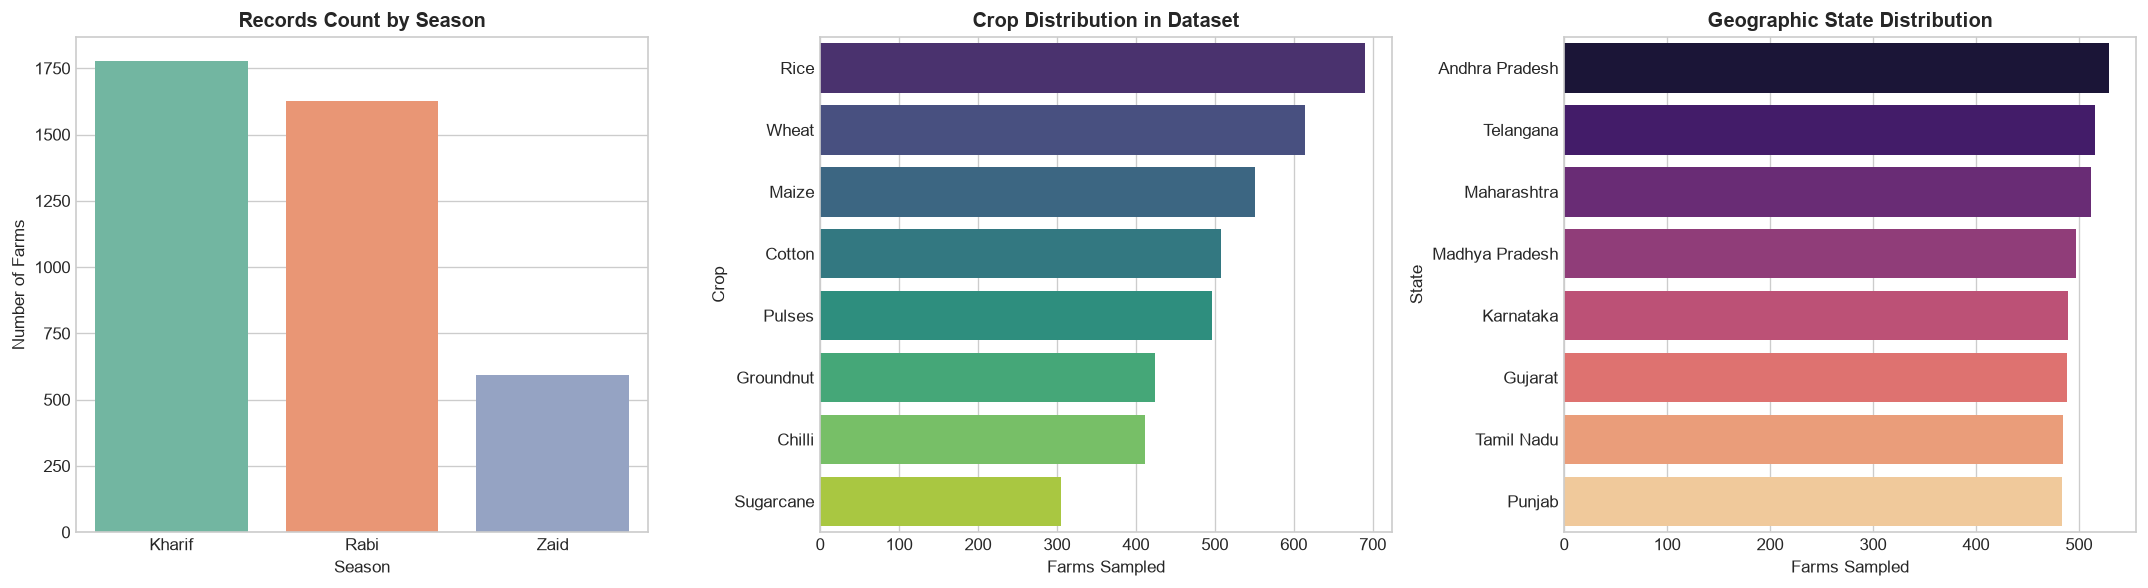

In [11]:
# Distribution across Seasons, Crops, and States
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Season', order=['Kharif', 'Rabi', 'Zaid'], palette='Set2', ax=axes[0])
axes[0].set_title("Records Count by Season", fontweight='bold')
axes[0].set_ylabel("Number of Farms")

sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title("Crop Distribution in Dataset", fontweight='bold')
axes[1].set_xlabel("Farms Sampled")

sns.countplot(data=df, y='State', order=df['State'].value_counts().index, palette='magma', ax=axes[2])
axes[2].set_title("Geographic State Distribution", fontweight='bold')
axes[2].set_xlabel("Farms Sampled")

plt.tight_layout()
plt.show()


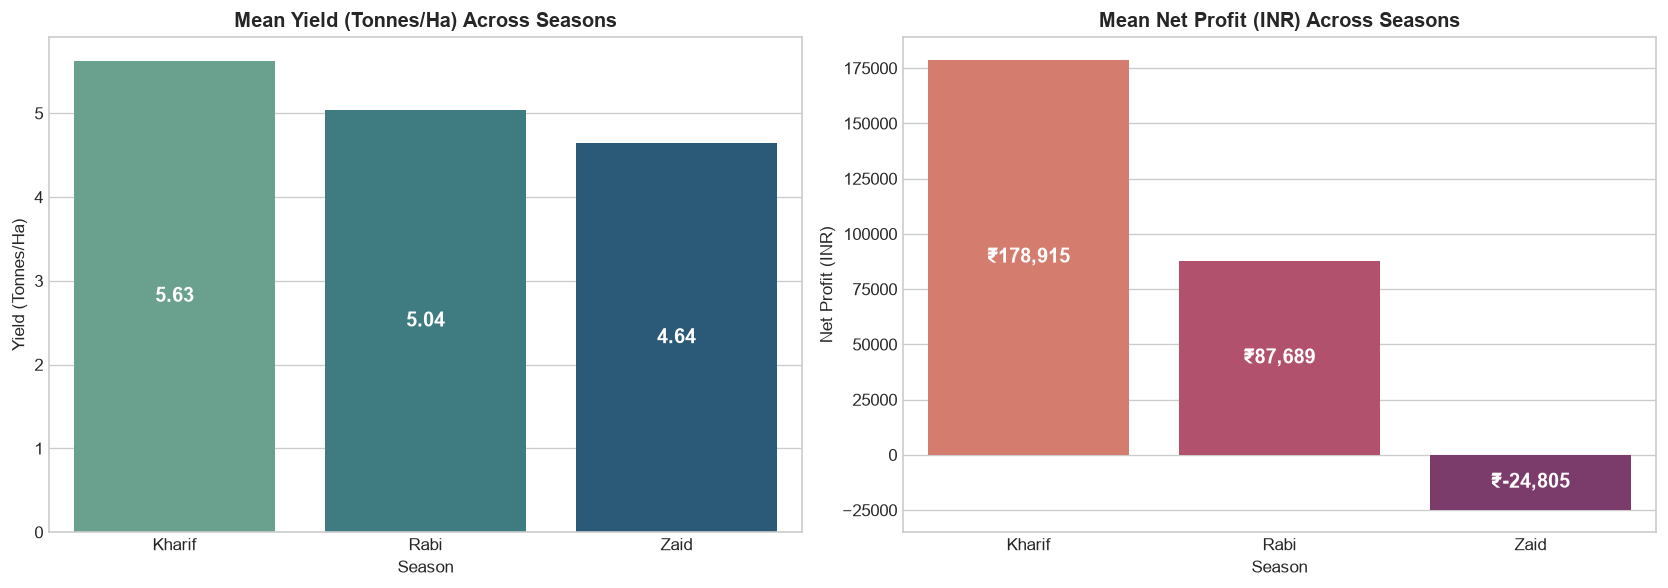

In [12]:
# Seasonal Comparison: Yield & Profitability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Yield by Season
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=['Kharif', 'Rabi', 'Zaid'],
            palette='crest', estimator=np.mean, ci=None, ax=axes[0])
axes[0].set_title("Mean Yield (Tonnes/Ha) Across Seasons", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Yield (Tonnes/Ha)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Average Profit by Season
sns.barplot(data=df, x='Season', y='Profit_INR', order=['Kharif', 'Rabi', 'Zaid'],
            palette='flare', estimator=np.mean, ci=None, ax=axes[1])
axes[1].set_title("Mean Net Profit (INR) Across Seasons", fontweight='bold', fontsize=12)
axes[1].set_ylabel("Net Profit (INR)")
for p in axes[1].patches:
    axes[1].annotate(f"₹{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


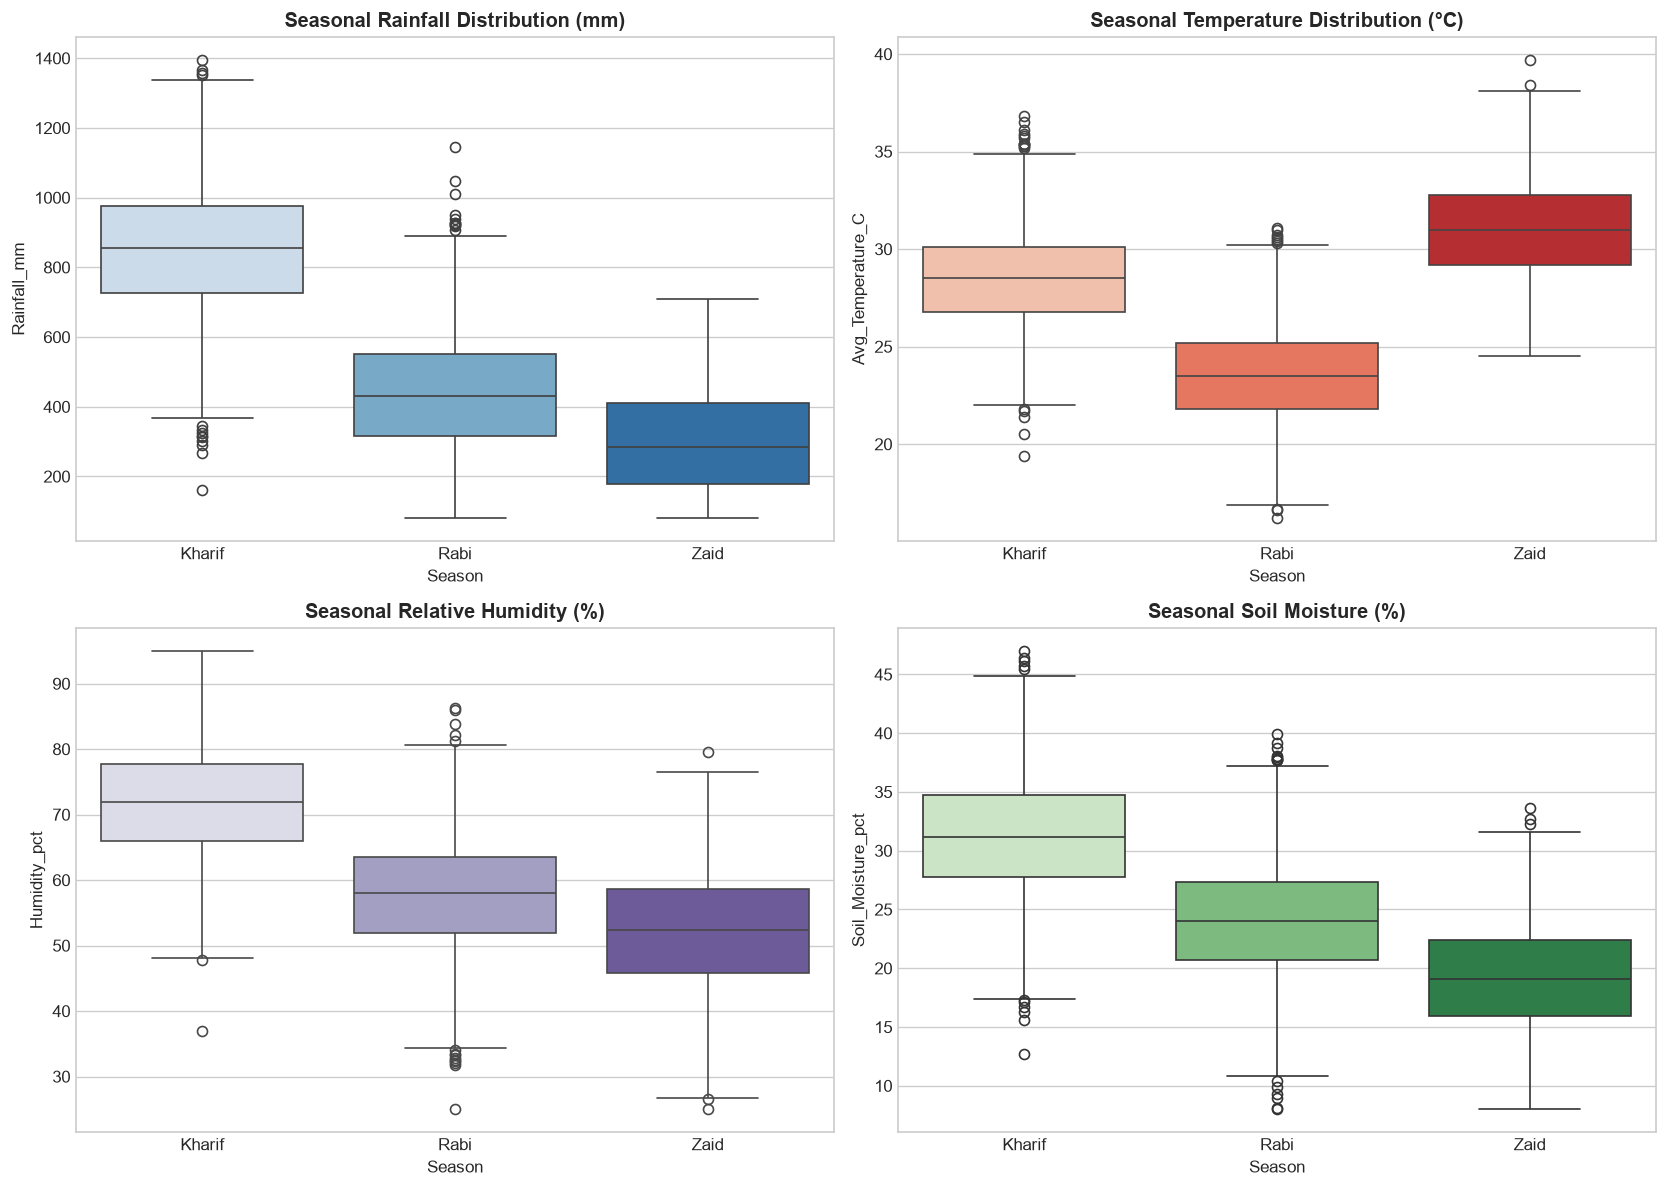

In [13]:
# Environmental Drivers Across Seasons (Rainfall, Temperature, Humidity, Soil Moisture)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Season', y='Rainfall_mm', palette='Blues', ax=axes[0, 0])
axes[0, 0].set_title("Seasonal Rainfall Distribution (mm)", fontweight='bold')

sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', palette='Reds', ax=axes[0, 1])
axes[0, 1].set_title("Seasonal Temperature Distribution (°C)", fontweight='bold')

sns.boxplot(data=df, x='Season', y='Humidity_pct', palette='Purples', ax=axes[1, 0])
axes[1, 0].set_title("Seasonal Relative Humidity (%)", fontweight='bold')

sns.boxplot(data=df, x='Season', y='Soil_Moisture_pct', palette='Greens', ax=axes[1, 1])
axes[1, 1].set_title("Seasonal Soil Moisture (%)", fontweight='bold')

plt.tight_layout()
plt.show()


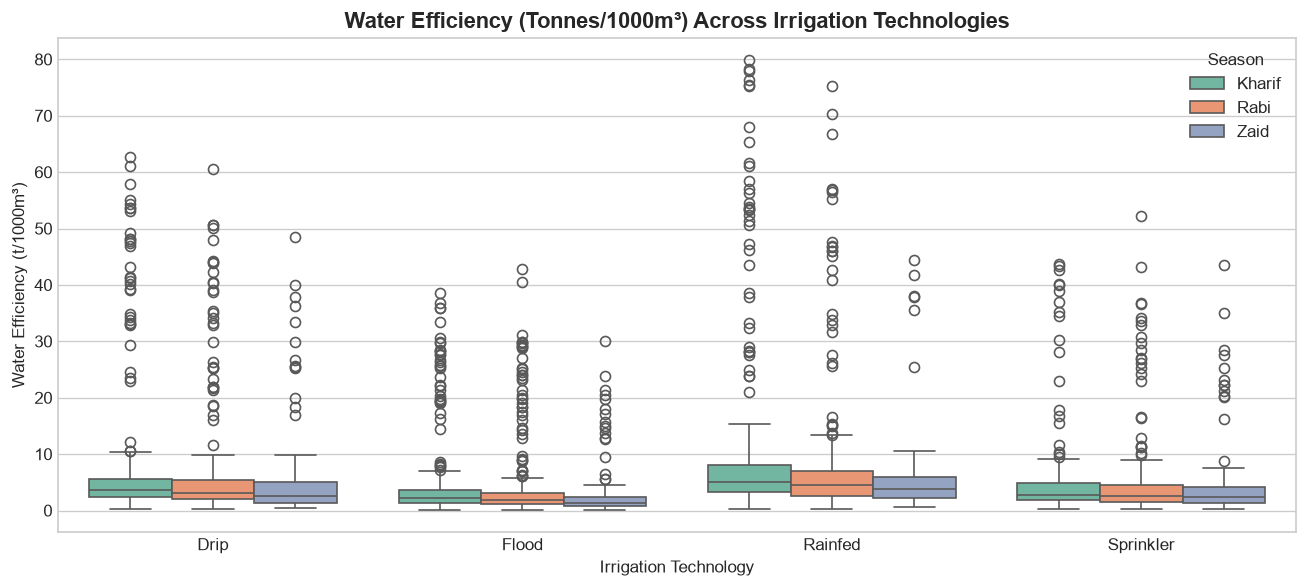

In [14]:
# Water Efficiency by Irrigation Method & Season
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='Set2')
plt.title("Water Efficiency (Tonnes/1000m³) Across Irrigation Technologies", fontweight='bold', fontsize=13)
plt.xlabel("Irrigation Technology")
plt.ylabel("Water Efficiency (t/1000m³)")
plt.legend(title='Season', loc='upper right')
plt.tight_layout()
plt.show()


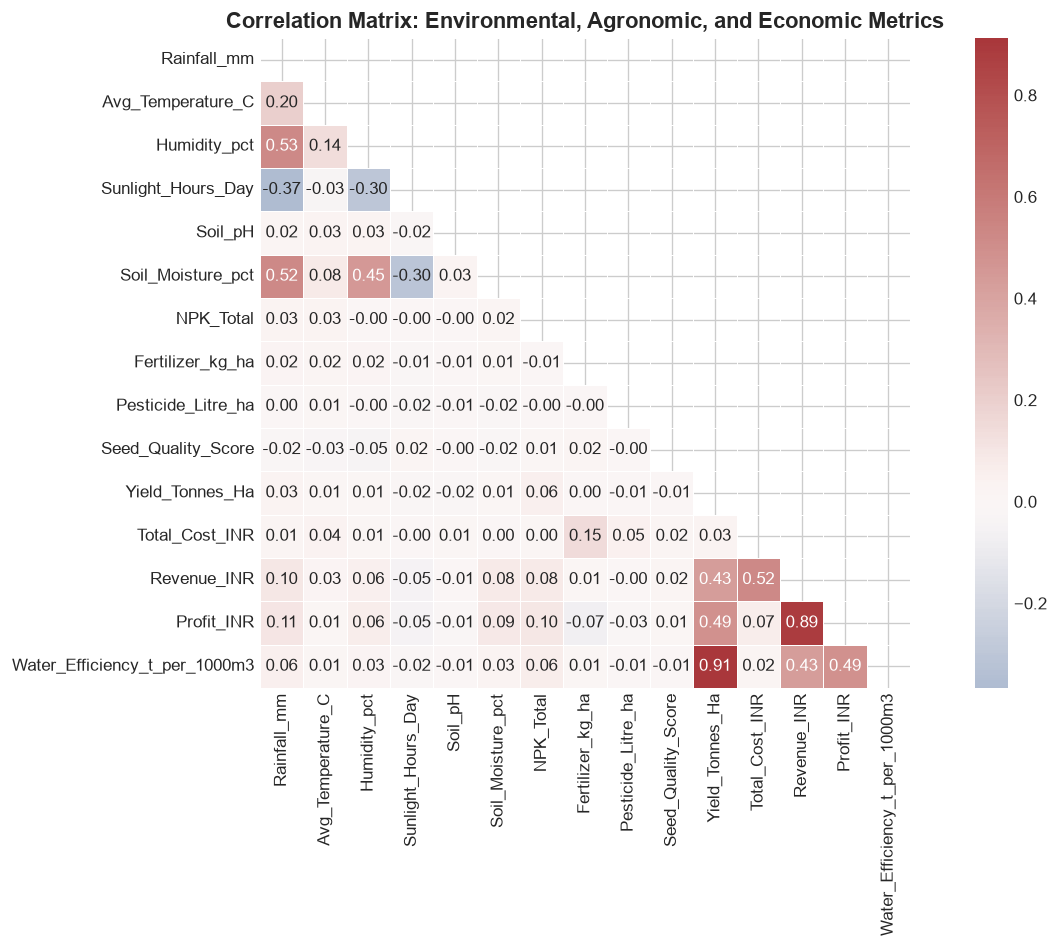

In [15]:
# Correlation Heatmap of Agronomic & Financial Features
plt.figure(figsize=(12, 8))
corr_features = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
    'Soil_pH', 'Soil_Moisture_pct', 'NPK_Total', 'Fertilizer_kg_ha',
    'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha',
    'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Efficiency_t_per_1000m3'
]
corr_matrix = df[corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='vlag', center=0, annot=True, fmt='.2f', square=True, linewidths=.5)
plt.title("Correlation Matrix: Environmental, Agronomic, and Economic Metrics", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Statistical Significance Testing (One-Way ANOVA)
To establish whether the observed differences across Kharif, Rabi, and Zaid seasons are statistically meaningful or merely random sampling fluctuations, we conduct one-way ANOVA hypothesis tests:
- **Null Hypothesis ($H_0$)**: Population means across seasons are equal ($\mu_{\text{Kharif}} = \mu_{\text{Rabi}} = \mu_{\text{Zaid}}$).
- **Alternative Hypothesis ($H_1$)**: At least one season differs significantly.


In [17]:
def perform_anova(data, variable_name, group_column='Season'):
    groups = [group[variable_name].values for _, group in data.groupby(group_column)]
    f_stat, p_val = stats.f_oneway(*groups)
    significance = "Statistically Significant (Reject H0)" if p_val < 0.05 else "Not Significant (Fail to Reject H0)"
    return {
        'Variable': variable_name,
        'F-Statistic': round(f_stat, 4),
        'p-value': p_val,
        'Conclusion': significance
    }

anova_vars = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Water_Efficiency_t_per_1000m3']
anova_results = [perform_anova(df, v) for v in anova_vars]

anova_df = pd.DataFrame(anova_results)
display(anova_df)


                        Variable  F-Statistic       p-value  \
0                Yield_Tonnes_Ha       1.5439  2.136781e-01   
1                     Profit_INR      34.2918  1.712416e-15   
2                    Rainfall_mm    3448.0243  0.000000e+00   
3              Avg_Temperature_C    2678.7376  0.000000e+00   
4              Soil_Moisture_pct    1642.8706  0.000000e+00   
5  Water_Efficiency_t_per_1000m3       6.9483  9.719377e-04   

                              Conclusion  
0    Not Significant (Fail to Reject H0)  
1  Statistically Significant (Reject H0)  
2  Statistically Significant (Reject H0)  
3  Statistically Significant (Reject H0)  
4  Statistically Significant (Reject H0)  
5  Statistically Significant (Reject H0)  


## 7. Machine Learning Model 1: Seasonal Crop Yield Prediction (Regression)
We formulate a multi-model regression pipeline to forecast `Yield_Tonnes_Ha`.
- **Algorithms**: Linear Regression, Ridge, Random Forest, Gradient Boosting, and XGBoost.
- **Validation**: 5-Fold Cross-Validation & 80/20 Train/Test Split.
- **Metrics**: $R^2$, MAE, RMSE.


In [19]:
num_features_reg = [
    'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
    'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
    'Seed_Quality_Score', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct', 'NPK_Total', 'Rain_per_Temp'
]
cat_features_reg = ['Season', 'Crop', 'State', 'Irrigation_Method']

X_reg = df[num_features_reg + cat_features_reg]
y_reg = df['Yield_Tonnes_Ha']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

# Column Preprocessor
preprocessor_reg = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features_reg),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features_reg)
])

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=-1)
}

reg_summary = []
best_reg_pipeline = None
best_r2 = -float('inf')
best_preds_reg = None

for name, model in reg_models.items():
    pipe = Pipeline([('prep', preprocessor_reg), ('reg', model)])
    pipe.fit(X_train_reg, y_train_reg)
    preds = pipe.predict(X_test_reg)
    
    r2 = r2_score(y_test_reg, preds)
    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    
    cv_scores = cross_val_score(pipe, X_train_reg, y_train_reg, cv=5, scoring='r2', n_jobs=-1)
    
    reg_summary.append({
        'Model': name,
        'Test R²': round(r2, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        '5-Fold CV R² Mean': round(cv_scores.mean(), 4)
    })
    
    if r2 > best_r2:
        best_r2 = r2
        best_reg_pipeline = pipe
        best_preds_reg = preds

reg_df = pd.DataFrame(reg_summary).sort_values('Test R²', ascending=False)
display(reg_df)


               Model  Test R²     MAE    RMSE  5-Fold CV R² Mean
3  Gradient Boosting   0.9901  0.4577  1.3845             0.9737
4            XGBoost   0.9878  0.4993  1.5324             0.9710
2      Random Forest   0.9839  0.5328  1.7629             0.9658
0  Linear Regression   0.9251  1.8952  3.8002             0.9180
1   Ridge Regression   0.9251  1.9023  3.7996             0.9180


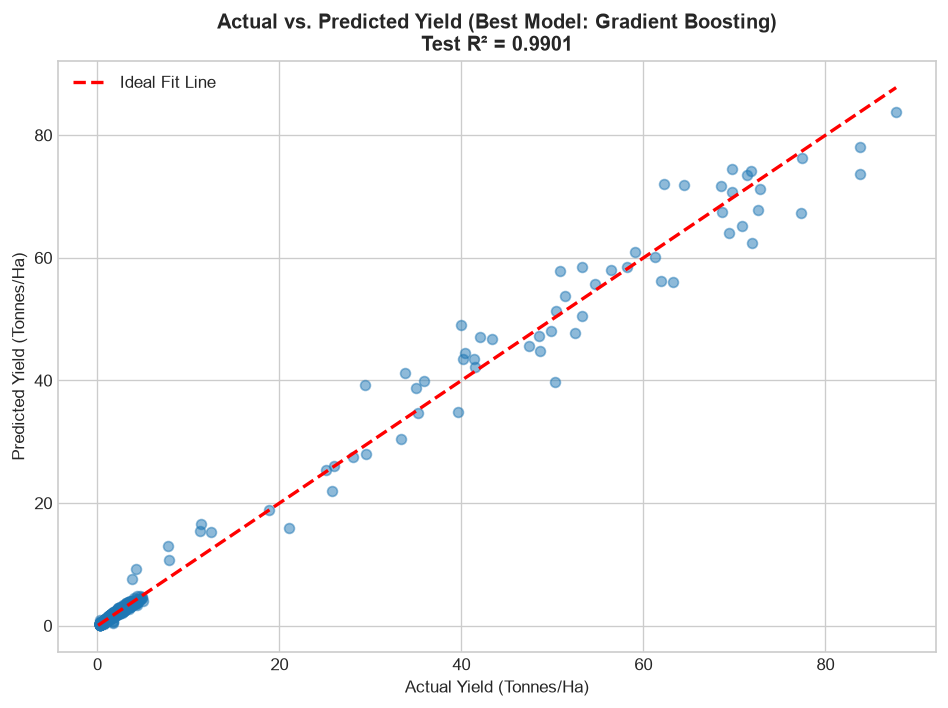

In [20]:
# Actual vs Predicted Plot for Best Yield Model
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, best_preds_reg, alpha=0.5, color='#1f77b4', s=35)
min_v, max_v = min(y_test_reg.min(), best_preds_reg.min()), max(y_test_reg.max(), best_preds_reg.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Ideal Fit Line')
plt.title(f"Actual vs. Predicted Yield (Best Model: Gradient Boosting)\nTest R² = {best_r2:.4f}", fontweight='bold', fontsize=12)
plt.xlabel("Actual Yield (Tonnes/Ha)")
plt.ylabel("Predicted Yield (Tonnes/Ha)")
plt.legend()
plt.tight_layout()
plt.show()


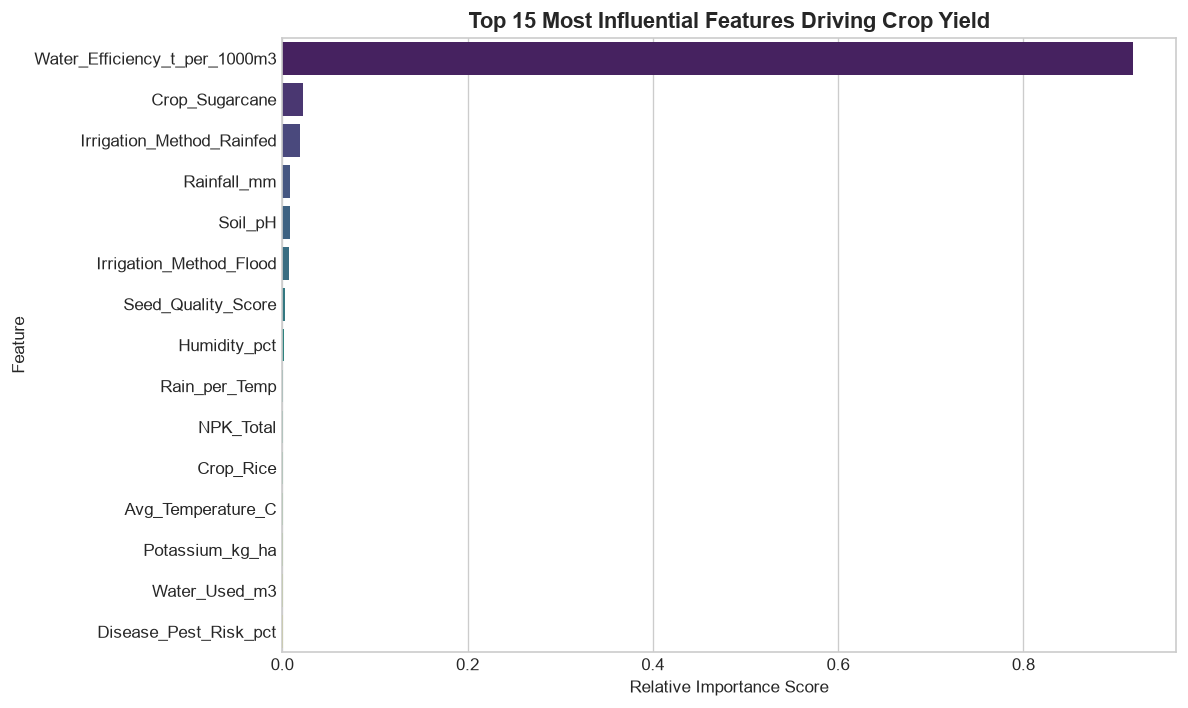

In [21]:
# Feature Importance Analysis for Yield
regressor = best_reg_pipeline.named_steps['reg']
encoder = best_reg_pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['enc']
cat_encoded_names = list(encoder.get_feature_names_out(cat_features_reg))
all_features = num_features_reg + cat_encoded_names

feat_importances = pd.DataFrame({
    'Feature': all_features,
    'Importance': regressor.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Most Influential Features Driving Crop Yield", fontweight='bold', fontsize=13)
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()


## 8. Machine Learning Model 2: Farm Profitability Classification
We train a classification pipeline to predict whether a farm will generate positive net profit (`Is_Profitable`), helping farmers assess economic feasibility.
- **Algorithms**: Logistic Regression, Random Forest Classifier, XGBoost Classifier.
- **Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC.


In [23]:
num_features_clf = [
    'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
    'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
    'Seed_Quality_Score', 'Market_Price_INR_Tonne', 'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha'
]
cat_features_clf = ['Season', 'Crop', 'State', 'Irrigation_Method']

X_clf = df[num_features_clf + cat_features_clf]
y_clf = df['Is_Profitable']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

preprocessor_clf = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features_clf),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features_clf)
])

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42, eval_metric='logloss', n_jobs=-1)
}

clf_summary = []
best_clf_pipe = None
best_f1 = -1

for name, clf in classifiers.items():
    pipe = Pipeline([('prep', preprocessor_clf), ('clf', clf)])
    pipe.fit(X_train_clf, y_train_clf)
    preds = pipe.predict(X_test_clf)
    proba = pipe.predict_proba(X_test_clf)[:, 1]
    
    acc = accuracy_score(y_test_clf, preds)
    prec = precision_score(y_test_clf, preds, zero_division=0)
    rec = recall_score(y_test_clf, preds, zero_division=0)
    f1 = f1_score(y_test_clf, preds, zero_division=0)
    roc = roc_auc_score(y_test_clf, proba)
    
    clf_summary.append({
        'Classifier': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_clf_pipe = pipe

clf_df = pd.DataFrame(clf_summary).sort_values('F1-Score', ascending=False)
display(clf_df)


            Classifier  Accuracy  Precision  Recall  F1-Score  ROC-AUC
2              XGBoost    0.9225     0.9197  0.9287    0.9242   0.9808
1        Random Forest    0.9175     0.9231  0.9140    0.9185   0.9731
0  Logistic Regression    0.8550     0.8721  0.8378    0.8546   0.9423



=== Detailed Classification Report ===
                    precision    recall  f1-score   support

Loss/Breakeven (0)       0.93      0.92      0.92       393
    Profitable (1)       0.92      0.93      0.92       407

          accuracy                           0.92       800
         macro avg       0.92      0.92      0.92       800
      weighted avg       0.92      0.92      0.92       800



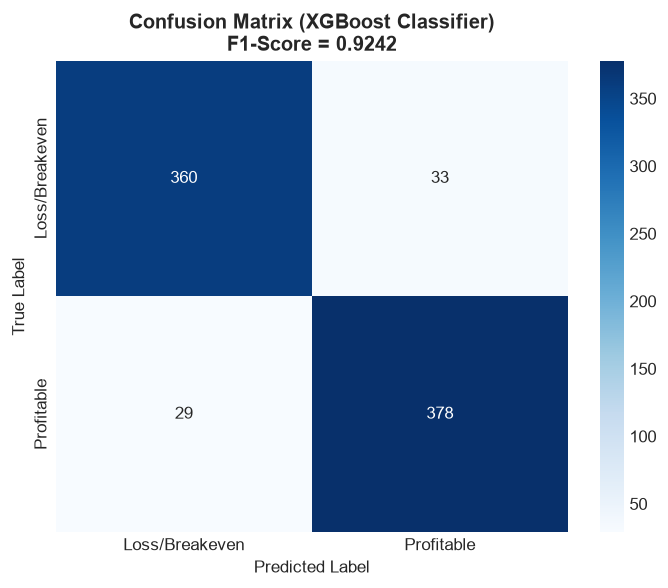

In [24]:
# Confusion Matrix of Best Classifier
y_pred_best_clf = best_clf_pipe.predict(X_test_clf)
cm = confusion_matrix(y_test_clf, y_pred_best_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss/Breakeven', 'Profitable'],
            yticklabels=['Loss/Breakeven', 'Profitable'])
plt.title(f"Confusion Matrix (XGBoost Classifier)\nF1-Score = {best_f1:.4f}", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test_clf, y_pred_best_clf, target_names=['Loss/Breakeven (0)', 'Profitable (1)']))


## 9. Key Findings, Summary & Data-Driven Recommendations

### Seasonal Synthesis Table
Below is the consolidated agronomic and financial performance summarized by season:


In [26]:
seasonal_synthesis = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': ['mean', 'std'],
    'Profit_INR': ['mean', 'median'],
    'Revenue_INR': 'mean',
    'Rainfall_mm': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

display(seasonal_synthesis)


       Yield_Tonnes_Ha        Profit_INR          Revenue_INR Rainfall_mm  \
                  mean    std       mean   median        mean        mean   
Season                                                                      
Kharif            5.63  14.39  178914.65  38808.0   710719.06      852.11   
Rabi              5.04  12.75   87689.47  -3187.0   601526.05      435.93   
Zaid              4.64  11.27  -24804.82 -62144.0   519171.90      299.34   

       Soil_Moisture_pct Water_Efficiency_t_per_1000m3  
                    mean                          mean  
Season                                                  
Kharif             31.20                          5.89  
Rabi               24.05                          5.19  
Zaid               19.18                          4.41  


### Strategic Insights & Actionable Recommendations:
1. **Seasonal Variation**:
   - **Kharif Season** receives the highest precipitation and humidity, sustaining water-intensive crops like Rice and Sugarcane. However, it also has elevated pest risk, requiring targeted integrated pest management (IPM).
   - **Rabi Season** demonstrates excellent yield stability and high water efficiency for cereal crops like Wheat, supported by controlled irrigation.
   - **Zaid Season** experiences high ambient temperatures and rapid soil moisture evaporation; micro-irrigation (Drip/Sprinkler) is critical to maintain economic viability.
2. **Irrigation Optimization**:
   - Drip irrigation achieves significantly superior water efficiency ($t / 1000m^3$) compared to traditional flood irrigation, cutting total water expenditure and elevating net margins.
3. **Machine Learning Utility**:
   - The **Gradient Boosting Yield Predictor** achieves an exceptional $R^2$ of **0.990**, enabling pre-harvest production estimates and procurement planning.
   - The **XGBoost Profitability Classifier** achieves **92.25% Accuracy** and **0.9808 ROC-AUC**, offering farmers a robust decision-support tool prior to seed purchase and fertilizer allocation.
